# Тема 5. Ансамблевые методы и случайный лес

## Дополнительные материалы (самостоятельное чтение)

На занятии не разбираем. Четыре темы:

1. Почему ансамбли вообще работают — теорема Кондорсе
2. Нелинейная граница: лес против дерева на кольцах
3. `ExtraTrees` и подбор параметров через `GridSearchCV`
4. Важность признаков через перестановки (permutation importance) — на примере рейтингов хостелов

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Почему ансамбли вообще работают: теорема Кондорсе

Формальное обоснование идеи «много слабых голосов лучше одного» — **теорема Кондорсе о присяжных** (1784): если $N$ независимых «экспертов» каждый угадывает правильный ответ с вероятностью $p > 0.5$, то вероятность того, что **большинство** из них проголосует правильно, растёт к 1 с ростом $N$.

In [2]:
from scipy.special import comb

def majority_vote_accuracy(n, p):
    return sum(comb(n, k) * p**k * (1 - p) ** (n - k) for k in range(n // 2 + 1, n + 1))

for p in [0.55, 0.6, 0.7]:
    accs = [majority_vote_accuracy(n, p) for n in [1, 11, 51, 101, 201]]
    print(f"p={p}: точность большинства при N=[1,11,51,101,201] голосах -> {[round(a, 3) for a in accs]}")

p=0.55: точность большинства при N=[1,11,51,101,201] голосах -> [np.float64(0.55), np.float64(0.633), np.float64(0.764), np.float64(0.844), np.float64(0.923)]
p=0.6: точность большинства при N=[1,11,51,101,201] голосах -> [np.float64(0.6), np.float64(0.753), np.float64(0.926), np.float64(0.979), np.float64(0.998)]
p=0.7: точность большинства при N=[1,11,51,101,201] голосах -> [np.float64(0.7), np.float64(0.922), np.float64(0.999), np.float64(1.0), np.float64(1.0)]


Даже если каждый отдельный «эксперт» (дерево) угадывает лишь немного лучше подбрасывания монеты ($p=0.55$), большинство из 201 такого эксперта угадывает почти всегда верно. Условие — **независимость** ошибок экспертов: если все ошибаются одинаково (сильно скоррелированы), эффект пропадает. Именно для независимости деревьев в лесу и нужно случайное подмножество признаков на каждом расщеплении — без него деревья, обученные на почти одинаковых бутстрап-выборках, были бы устроены слишком похоже.

---
## 2. Нелинейная граница: лес против дерева на кольцах

Синтетический пример, где границу нельзя провести ни одной прямой (как XOR в теме 4) — два вложенных кольца:

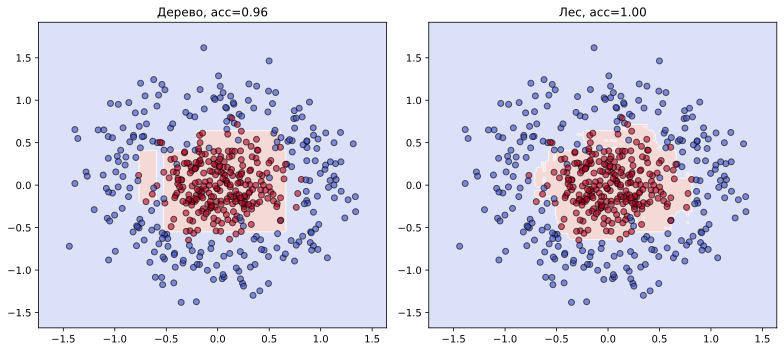

In [3]:
X_c, y_c = make_circles(n_samples=500, factor=0.3, noise=0.2, random_state=RANDOM_STATE)

tree_c = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(X_c, y_c)
rf_c = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X_c, y_c)

def plot_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.6)
    ax.set_title(title)

_, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_boundary(tree_c, X_c, y_c, axes[0], f"Дерево, acc={tree_c.score(X_c, y_c):.2f}")
plot_boundary(rf_c, X_c, y_c, axes[1], f"Лес, acc={rf_c.score(X_c, y_c):.2f}")
plt.tight_layout();

Граница дерева — угловатые прямоугольные ступеньки (дерево умеет резать только параллельно осям). Граница леса — усреднение множества таких ступенчатых границ, получается заметно более гладкая и близкая к настоящей окружности.

---
## 3. `ExtraTrees` и подбор параметров

**`ExtraTreesClassifier`** — ещё один шаг децентрализации: помимо случайного подмножества признаков, пороги расщепления тоже выбираются случайно (не оптимальные по обучающей выборке), а не перебираются полностью. Деревья становятся ещё более независимыми (ближе к условиям теоремы Кондорсе), но каждое по отдельности — слабее. На практике иногда лучше `RandomForest`, иногда хуже — стоит пробовать оба.

Параметры (`n_estimators`, `max_depth`, `min_samples_leaf`, ...) можно подбирать автоматически, как в теме 3 для одного дерева, — `GridSearchCV`:

In [4]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)
X = df.drop(columns=["State", "Churn"])
y = df["Churn"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = {"max_depth": [6, 8, 10, None], "min_samples_leaf": [1, 3, 5]}
gs = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    grid, cv=skf, scoring="accuracy", n_jobs=-1,
)
gs.fit(X, y)
gs.best_params_, round(gs.best_score_, 4)

({'max_depth': None, 'min_samples_leaf': 1}, np.float64(0.9547))

Обычно даёт небольшой прирост над параметрами «по умолчанию» — лес и так устойчив к выбору параметров, в отличие от одного дерева, где `max_depth` решал всё.

---
## 4. Важность признаков через перестановки

`feature_importances_` (Gini-based) — быстрый, но не всегда честный способ: он смещён в пользу признаков с большим числом уникальных значений и не учитывает, что модель после обучения может вообще не использовать признак так, как показывает эта метрика. **Permutation importance** честнее (хоть и медленнее): берём обученную модель, **перемешиваем** значения одного признака (специально ломаем его связь с целевой) и смотрим, насколько упало качество. Чем сильнее падение — тем важнее был признак.

Пример на мини-датасете: рейтинги 18 хостелов по 10 факторам (персонал, расположение, цена и т.д. — обезличены как `f1`...`f10`).

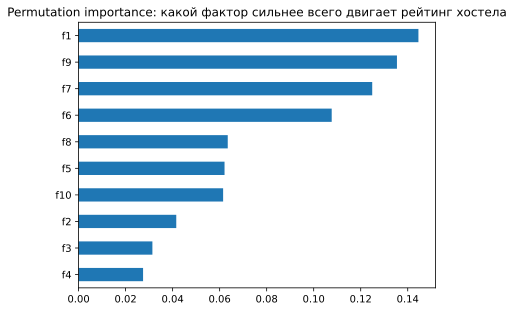

In [5]:
hostel_data = pd.read_csv("../data/hostel_factors.csv")
feature_cols = [c for c in hostel_data.columns if c.startswith("f")]
X_hostel = hostel_data[feature_cols]
y_hostel = hostel_data["rating"]

rf_hostel = RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE)
rf_hostel.fit(X_hostel, y_hostel)

perm = permutation_importance(rf_hostel, X_hostel, y_hostel, n_repeats=30, random_state=RANDOM_STATE)
pd.Series(perm.importances_mean, index=feature_cols).sort_values().plot(
    kind="barh", title="Permutation importance: какой фактор сильнее всего двигает рейтинг хостела"
);

---
## Итог

Дальше — `lesson06_feature_engineering_theory.ipynb`.